# NHS A&E 2020-21 to February 2026 SQL Portfolio Project

## Project Goal
This project analyses NHS A&E performance data from 2020-21 to February 2026 using:

- Python
- Pandas
- SQLite
- SQL
- Matplotlib / Seaborn

## Objectives
- Clean and prepare the dataset
- Load it into SQLite
- Answer business questions with SQL
- Create portfolio-ready insights and visuals

In [112]:
import pandas as pd
import numpy as np
import sqlite3
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [113]:
# Set file paths
raw_data_folder = "../data/raw"
processed_folder = "../data/processed"

processed_data_path = os.path.join(processed_folder, "nhs_ae_full_2020_2026.csv")
regional_summary_path = os.path.join(processed_folder, "regional_summary_2020_2026.csv")
top_over4_path = os.path.join(processed_folder, "top_10_over4_waits_2020_2026.csv")
top_12plus_path = os.path.join(processed_folder, "top_10_12plus_waits_2020_2026.csv")

db_path = "../nhs_ae_2020_2026.db"
table_name = "nhs_ae_waiting_times"

In [114]:
# Check for CSV files in the raw data folder
csv_files = glob(os.path.join(raw_data_folder, "*.csv"))

print(f"Number of CSV files found: {len(csv_files)}")
csv_files[:10]

Number of CSV files found: 71


['../data/raw/April-2020-revised-260421-abc123.csv',
 '../data/raw/April-2021-revised-120522-ABC456.csv',
 '../data/raw/April-2022-revised-130624-F4scP.csv',
 '../data/raw/April-2023-revised-130624-defv1.csv',
 '../data/raw/April-2025-CSV-revised.csv',
 '../data/raw/August-2020-revised-270421-gh920.csv',
 '../data/raw/August-2021-revised-120522-CCC324.csv',
 '../data/raw/August-2022-revised-110523-eee555.csv',
 '../data/raw/August-2023-revised-130624-ndx091.csv',
 '../data/raw/August-2025-CSV-revised.csv']

In [115]:
# Load and clean each CSV file, then combine into a single DataFrame
raw_data_folder = "../data/raw"
csv_files = glob(os.path.join(raw_data_folder, "*.csv"))

def load_and_clean_file(file_path):
    df = pd.read_csv(file_path)

    # Drop fully empty columns
    df = df.dropna(axis=1, how="all")

    # Drop unnamed junk columns
    df = df.loc[:, ~df.columns.str.contains("^Unnamed", na=False)]

    # Drop weird single-letter junk columns
    if "a" in df.columns:
        df = df.drop(columns=["a"])

    # Drop fully empty rows
    df = df.dropna(how="all")

    # Remove total rows
    for col in ["Org Code", "Org name", "Parent Org"]:
        if col in df.columns:
            df = df[~df[col].astype(str).str.strip().str.upper().eq("TOTAL")]

    # Add source file
    df["source_file"] = os.path.basename(file_path)

    return df

all_dfs = [load_and_clean_file(file) for file in csv_files]
df = pd.concat(all_dfs, ignore_index=True)

print(f"Combined shape: {df.shape}")
df.head()

Combined shape: (14529, 23)


,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,Attendances over 4hrs Type 1,Attendances over 4hrs Type 2,Attendances over 4hrs Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,source_file,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department
0,MSitAE-APRIL-2020,Y02572,NHS ENGLAND NORTH EAST AND YORKSHIRE,PARK COMMUNITY PRACTICE,0,0,0,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
1,MSitAE-APRIL-2020,RY8,NHS ENGLAND MIDLANDS,DERBYSHIRE COMMUNITY HEALTH SERVICES NHS FOUND...,0,0,2626,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
2,MSitAE-APRIL-2020,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,833,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
3,MSitAE-APRIL-2020,Y02532,NHS ENGLAND NORTH WEST,MIRIAM MINOR EMERGENCY,0,0,507,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
4,MSitAE-APRIL-2020,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,955,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
# Clean and standardize the "Period" column
df["Period"] = (
    df["Period"]
    .astype(str)
    .str.strip()
    .str.replace("MSitAE-", "", regex=False)
    .str.title()
)

df["Period"] = pd.to_datetime(df["Period"], format="%B-%Y", errors="coerce")

In [117]:
# Check for null values in the "Period" column
df["Period"].isna().sum()
df = df.rename(columns={"Period": "period"})

In [118]:
# Explore the unique values in the "period" column
print(df["period"].head(20))
print(df["period"].dtype)
print(df["period"].dropna().astype(str).head(20).tolist())

0    2020-04-01
1    2020-04-01
2    2020-04-01
3    2020-04-01
4    2020-04-01
5    2020-04-01
6    2020-04-01
7    2020-04-01
8    2020-04-01
9    2020-04-01
10   2020-04-01
11   2020-04-01
12   2020-04-01
13   2020-04-01
14   2020-04-01
15   2020-04-01
16   2020-04-01
17   2020-04-01
18   2020-04-01
19   2020-04-01
Name: period, dtype: datetime64[ns]
datetime64[ns]
['2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01', '2020-04-01']


In [119]:
# Check the distribution of source files
df["source_file"].value_counts().sort_index()

source_file
April-2020-revised-260421-abc123.csv        222
April-2021-revised-120522-ABC456.csv        210
April-2022-revised-130624-F4scP.csv         204
April-2023-revised-130624-defv1.csv         204
April-2025-CSV-revised.csv                  198
August-2020-revised-270421-gh920.csv        218
August-2021-revised-120522-CCC324.csv       210
August-2022-revised-110523-eee555.csv       200
August-2023-revised-130624-ndx091.csv       203
August-2025-CSV-revised.csv                 201
December-2020-revised-270421-fd675.csv      216
December-2021-revised-120522-abc323.csv     207
December-2022-revised-110523-iii999.csv     204
December-2023-revised-130624-nbe280.csv     202
December-2025-CSV-K7F4Sp.csv                197
February-2021-revised-280421-df123.csv      214
February-2022-revised-120522-cag124.csv     207
February-2023-revised-110523-kkk11b.csv     203
February-2024-revised-130624-ef123ty.csv    199
February-2026-CSV-Dl8t54.csv                197
January-2021-revised-280421-

In [120]:
df.shape

(14529, 23)

In [121]:
df.columns.tolist()

['period',
 'Org Code',
 'Parent Org',
 'Org name',
 'A&E attendances Type 1',
 'A&E attendances Type 2',
 'A&E attendances Other A&E Department',
 'Attendances over 4hrs Type 1',
 'Attendances over 4hrs Type 2',
 'Attendances over 4hrs Other Department',
 'Patients who have waited 4-12 hs from DTA to admission',
 'Patients who have waited 12+ hrs from DTA to admission',
 'Emergency admissions via A&E - Type 1',
 'Emergency admissions via A&E - Type 2',
 'Emergency admissions via A&E - Other A&E department',
 'Other emergency admissions',
 'source_file',
 'A&E attendances Booked Appointments Type 1',
 'A&E attendances Booked Appointments Type 2',
 'A&E attendances Booked Appointments Other Department',
 'Attendances over 4hrs Booked Appointments Type 1',
 'Attendances over 4hrs Booked Appointments Type 2',
 'Attendances over 4hrs Booked Appointments Other Department']

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14529 entries, 0 to 14528
Data columns (total 23 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   period                                                      14529 non-null  datetime64[ns]
 1   Org Code                                                    14529 non-null  object        
 2   Parent Org                                                  14529 non-null  object        
 3   Org name                                                    14529 non-null  object        
 4   A&E attendances Type 1                                      14529 non-null  int64         
 5   A&E attendances Type 2                                      14529 non-null  int64         
 6   A&E attendances Other A&E Department                        14529 non-null  int64         
 7   Attendances over 4hrs 

In [123]:
raw_df = df.copy()

In [124]:
# Explore the unique values in the "period" column again after cleaning
null_period_rows = df[df["period"].isna()].copy()
print(null_period_rows.shape)
null_period_rows[["period", "Org Code", "Org name", "source_file"]].head(20)

(0, 23)


,period,Org Code,Org name,source_file


In [125]:
# Check for any non-date values in the "period" column
raw_df[raw_df["period"].astype(str).str.contains("202", na=False) == False][["period"]].drop_duplicates().sort_values("period")

,period


In [126]:
# Clean column names
def clean_column_name(col):
    col = col.strip().lower()
    col = col.replace("&", "and")
    col = col.replace("+", "plus")
    col = col.replace("-", "_")
    col = col.replace("/", "_")
    col = col.replace(" ", "_")
    col = col.replace(".", "")
    return col

df.columns = [clean_column_name(col) for col in df.columns]
df.columns.tolist()

['period',
 'org_code',
 'parent_org',
 'org_name',
 'aande_attendances_type_1',
 'aande_attendances_type_2',
 'aande_attendances_other_aande_department',
 'attendances_over_4hrs_type_1',
 'attendances_over_4hrs_type_2',
 'attendances_over_4hrs_other_department',
 'patients_who_have_waited_4_12_hs_from_dta_to_admission',
 'patients_who_have_waited_12plus_hrs_from_dta_to_admission',
 'emergency_admissions_via_aande___type_1',
 'emergency_admissions_via_aande___type_2',
 'emergency_admissions_via_aande___other_aande_department',
 'other_emergency_admissions',
 'source_file',
 'aande_attendances_booked_appointments_type_1',
 'aande_attendances_booked_appointments_type_2',
 'aande_attendances_booked_appointments_other_department',
 'attendances_over_4hrs_booked_appointments_type_1',
 'attendances_over_4hrs_booked_appointments_type_2',
 'attendances_over_4hrs_booked_appointments_other_department']

In [127]:
# Check for duplicates based on org_code and period
duplicate_check = df.duplicated(subset=["org_code", "period"], keep=False)
df.loc[duplicate_check, ["org_code", "org_name", "period", "source_file"]].sort_values(["org_code", "period"]).head(20)

,org_code,org_name,period,source_file


In [128]:
# Count duplicates based on org_code and period
df.duplicated(subset=["org_code", "period"]).sum()

np.int64(0)

In [129]:
# Remove duplicates, keeping the first occurrence
df = df.drop_duplicates(subset=["org_code", "period"], keep="first")
print(df.shape)

(14529, 23)


In [130]:
# Preview cleaned Data
df.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,source_file,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department
0,2020-04-01,Y02572,NHS ENGLAND NORTH EAST AND YORKSHIRE,PARK COMMUNITY PRACTICE,0,0,0,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-04-01,RY8,NHS ENGLAND MIDLANDS,DERBYSHIRE COMMUNITY HEALTH SERVICES NHS FOUND...,0,0,2626,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-04-01,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,833,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-04-01,Y02532,NHS ENGLAND NORTH WEST,MIRIAM MINOR EMERGENCY,0,0,507,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-04-01,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,955,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
#Check numeric columns
df.dtypes

period                                                        datetime64[ns]
org_code                                                              object
parent_org                                                            object
org_name                                                              object
aande_attendances_type_1                                               int64
aande_attendances_type_2                                               int64
aande_attendances_other_aande_department                               int64
attendances_over_4hrs_type_1                                           int64
attendances_over_4hrs_type_2                                           int64
attendances_over_4hrs_other_department                                 int64
patients_who_have_waited_4_12_hs_from_dta_to_admission                 int64
patients_who_have_waited_12plus_hrs_from_dta_to_admission              int64
emergency_admissions_via_aande___type_1                                int64

In [132]:
# Convert attendance and admission columns to numeric
numeric_cols = [
    "aande_attendances_type_1",
    "aande_attendances_type_2",
    "aande_attendances_other_aande_department",
    "aande_attendances_booked_appointments_type_1",
    "aande_attendances_booked_appointments_type_2",
    "aande_attendances_booked_appointments_other_department",
    "attendances_over_4hrs_type_1",
    "attendances_over_4hrs_type_2",
    "attendances_over_4hrs_other_department",
    "attendances_over_4hrs_booked_appointments_type_1",
    "attendances_over_4hrs_booked_appointments_type_2",
    "attendances_over_4hrs_booked_appointments_other_department",
    "patients_who_have_waited_4_12_hs_from_dta_to_admission",
    "patients_who_have_waited_12plus_hrs_from_dta_to_admission",
    "emergency_admissions_via_aande___type_1",
    "emergency_admissions_via_aande___type_2",
    "emergency_admissions_via_aande___other_aande_department",
    "other_emergency_admissions"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [133]:
# Check for null values in numeric columns
df[numeric_cols].isnull().sum().sort_values(ascending=False).head(10)

aande_attendances_booked_appointments_type_2                  875
aande_attendances_booked_appointments_type_1                  875
attendances_over_4hrs_booked_appointments_other_department    875
attendances_over_4hrs_booked_appointments_type_2              875
aande_attendances_booked_appointments_other_department        875
attendances_over_4hrs_booked_appointments_type_1              875
aande_attendances_type_2                                        0
aande_attendances_type_1                                        0
aande_attendances_other_aande_department                        0
attendances_over_4hrs_type_1                                    0
dtype: int64

In [134]:
# This shows you which files are responsible for the NaNs
missing_by_file = df[df['aande_attendances_booked_appointments_type_1'].isnull()]
print(missing_by_file['source_file'].unique())


['April-2020-revised-260421-abc123.csv'
 'July-2020-revised-270421-cd305.csv' 'June-2020-revised-260421-df453.csv'
 'May-2020-revised-260421-de345.csv']


In [135]:
# Fill the missing 'Booked' values with 0 so you can keep the 2020 data
booked_cols = [col for col in df.columns if 'booked_appointments' in col]
df[booked_cols] = df[booked_cols].fillna(0)


# Function for feature engineering

In [136]:
def add_derived_metrics(dataframe):
    df = dataframe.copy()

    df["total_attendances"] = (
        df["aande_attendances_type_1"]
        + df["aande_attendances_type_2"]
        + df["aande_attendances_other_aande_department"]
    )

    df["total_booked_attendances"] = (
        df["aande_attendances_booked_appointments_type_1"]
        + df["aande_attendances_booked_appointments_type_2"]
        + df["aande_attendances_booked_appointments_other_department"]
    )

    df["total_over_4hrs"] = (
        df["attendances_over_4hrs_type_1"]
        + df["attendances_over_4hrs_type_2"]
        + df["attendances_over_4hrs_other_department"]
    )

    df["total_booked_over_4hrs"] = (
        df["attendances_over_4hrs_booked_appointments_type_1"]
        + df["attendances_over_4hrs_booked_appointments_type_2"]
        + df["attendances_over_4hrs_booked_appointments_other_department"]
    )

    df["total_dta_waits"] = (
        df["patients_who_have_waited_4_12_hs_from_dta_to_admission"]
        + df["patients_who_have_waited_12plus_hrs_from_dta_to_admission"]
    )

    df["total_emergency_admissions"] = (
        df["emergency_admissions_via_aande___type_1"]
        + df["emergency_admissions_via_aande___type_2"]
        + df["emergency_admissions_via_aande___other_aande_department"]
        + df["other_emergency_admissions"]
    )

    df["over_4hr_rate"] = np.where(
        df["total_attendances"] > 0,
        df["total_over_4hrs"] / df["total_attendances"],
        0
    )

    df["booked_over_4hr_rate"] = np.where(
        df["total_booked_attendances"] > 0,
        df["total_booked_over_4hrs"] / df["total_booked_attendances"],
        0
    )

    df["admission_rate"] = np.where(
        df["total_attendances"] > 0,
        df["total_emergency_admissions"] / df["total_attendances"],
        0
    )

    return df

In [137]:
df = add_derived_metrics(df)
df.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,source_file,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate
0,2020-04-01,Y02572,NHS ENGLAND NORTH EAST AND YORKSHIRE,PARK COMMUNITY PRACTICE,0,0,0,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0,0.0,0.0,0.0
1,2020-04-01,RY8,NHS ENGLAND MIDLANDS,DERBYSHIRE COMMUNITY HEALTH SERVICES NHS FOUND...,0,0,2626,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,0.0,0.0,0.0,0.0,0.0,0.0,2626,0.0,0,0.0,0,0,0.0,0.0,0.0
2,2020-04-01,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,833,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,0.0,0.0,0.0,0.0,0.0,0.0,833,0.0,0,0.0,0,0,0.0,0.0,0.0
3,2020-04-01,Y02532,NHS ENGLAND NORTH WEST,MIRIAM MINOR EMERGENCY,0,0,507,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,0.0,0.0,0.0,0.0,0.0,0.0,507,0.0,0,0.0,0,0,0.0,0.0,0.0
4,2020-04-01,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,955,0,0,0,0,0,0,0,0,0,April-2020-revised-260421-abc123.csv,0.0,0.0,0.0,0.0,0.0,0.0,955,0.0,0,0.0,0,0,0.0,0.0,0.0


In [138]:
# Sort the DataFrame by org_name and period
df = df.sort_values(["org_name", "period"]).reset_index(drop=True)

In [139]:
# Check the range of periods
print("Min period:", df["period"].min())
print("Max period:", df["period"].max())
print("Unique months:", df["period"].nunique())

Min period: 2020-04-01 00:00:00
Max period: 2026-02-01 00:00:00
Unique months: 71


In [140]:
# This shows you the most recent files and periods in the dataset
df[["period", "source_file"]].drop_duplicates().sort_values("period").tail(20)

,period,source_file
51,2024-07-01,Monthly-AE-July-2024-revised.csv
52,2024-08-01,Monthly-AE-August-2024.csv
53,2024-09-01,Monthly-AE-September-2024.csv
54,2024-10-01,Monthly-AE-October-2024-revised.csv
55,2024-11-01,Monthly-AE-November-2024-revised.csv
56,2024-12-01,Monthly-AE-December-2024.csv
57,2025-01-01,Monthly-AE-January-2025.csv
58,2025-02-01,Monthly-AE-February-2025-revised.csv
59,2025-03-01,Monthly-AE-March-2025.csv
60,2025-04-01,April-2025-CSV-revised.csv


In [141]:
# Organisation Coverage Check
df["org_name"].nunique()


260

In [142]:
# This shows you how many unique organisations are reporting in each month
df.groupby("period")["org_name"].nunique().reset_index(name="org_count").tail(12)

,period,org_count
59,2025-03-01,198
60,2025-04-01,198
61,2025-05-01,200
62,2025-06-01,201
63,2025-07-01,201
64,2025-08-01,201
65,2025-09-01,201
66,2025-10-01,196
67,2025-11-01,197
68,2025-12-01,197


In [143]:
# Summary Statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
period,14529,2023-02-11 10:14:17.815403776,2020-04-01 00:00:00,2021-08-01 00:00:00,2023-02-01 00:00:00,2024-08-01 00:00:00,2026-02-01 00:00:00,NaN
aande_attendances_type_1,14529.0,6306.125129,0.0,0.0,6104.0,10331.0,36434.0,6492.815318
aande_attendances_type_2,14529.0,203.675064,0.0,0.0,0.0,0.0,6577.0,637.480776
aande_attendances_other_aande_department,14529.0,3235.198706,0.0,222.0,2184.0,5052.0,20310.0,3504.64401
attendances_over_4hrs_type_1,14529.0,2223.721591,0.0,0.0,1213.0,3794.0,18083.0,2738.306314
attendances_over_4hrs_type_2,14529.0,6.797027,0.0,0.0,0.0,0.0,719.0,35.805414
attendances_over_4hrs_other_department,14529.0,112.909629,0.0,0.0,2.0,86.0,4808.0,299.782006
patients_who_have_waited_4_12_hs_from_dta_to_admission,14529.0,419.324799,0.0,0.0,193.0,666.0,8944.0,581.942247
patients_who_have_waited_12plus_hrs_from_dta_to_admission,14529.0,138.95891,0.0,0.0,0.0,115.0,2508.0,283.693738
emergency_admissions_via_aande___type_1,14529.0,1848.464106,0.0,0.0,1709.0,3031.0,11732.0,1951.957378


In [144]:
# Unique Organisations
df["org_name"].unique()

array(['AIREDALE NHS FOUNDATION TRUST',
       "ALDER HEY CHILDREN'S NHS FOUNDATION TRUST",
       "ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATION TRUST",
       'ASHFORD WALK-IN-CENTRE', 'ASSURA READING LLP',
       'ASSURA VERTIS URGENT CARE CENTRES (BIRMINGHAM)', 'BADGER LTD',
       'BARKING HOSPITAL UTC',
       'BARKING, HAVERING AND REDBRIDGE UNIVERSITY HOSPITALS NHS TRUST',
       'BARNSLEY HOSPITAL NHS FOUNDATION TRUST', 'BARTS HEALTH NHS TRUST',
       'BECKENHAM BEACON UCC',
       'BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST',
       'BERKSHIRE HEALTHCARE NHS FOUNDATION TRUST', 'BIRMINGHAM WIC',
       "BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATION TRUST",
       'BLACKPOOL TEACHING HOSPITALS NHS FOUNDATION TRUST',
       'BOLTON NHS FOUNDATION TRUST', 'BRACKNELL URGENT CARE CENTRE WIC',
       'BRADFORD TEACHING HOSPITALS NHS FOUNDATION TRUST',
       'BRANSHOLME HEALTH CENTRE',
       'BRIDGEWATER COMMUNITY HEALTHCARE NHS FOUNDATION TRUST',
       'BRIDLINGTON HOSPITA

In [145]:
# Period values
df["period"].unique()

<DatetimeArray>
['2020-04-01 00:00:00', '2020-05-01 00:00:00', '2020-06-01 00:00:00',
 '2020-07-01 00:00:00', '2020-08-01 00:00:00', '2020-09-01 00:00:00',
 '2020-10-01 00:00:00', '2020-11-01 00:00:00', '2020-12-01 00:00:00',
 '2021-01-01 00:00:00', '2021-02-01 00:00:00', '2021-03-01 00:00:00',
 '2021-04-01 00:00:00', '2021-05-01 00:00:00', '2021-06-01 00:00:00',
 '2021-07-01 00:00:00', '2021-08-01 00:00:00', '2021-09-01 00:00:00',
 '2021-10-01 00:00:00', '2021-11-01 00:00:00', '2021-12-01 00:00:00',
 '2022-01-01 00:00:00', '2022-02-01 00:00:00', '2022-03-01 00:00:00',
 '2022-04-01 00:00:00', '2022-05-01 00:00:00', '2022-06-01 00:00:00',
 '2022-07-01 00:00:00', '2022-08-01 00:00:00', '2022-09-01 00:00:00',
 '2022-10-01 00:00:00', '2022-11-01 00:00:00', '2022-12-01 00:00:00',
 '2023-01-01 00:00:00', '2023-02-01 00:00:00', '2023-03-01 00:00:00',
 '2023-04-01 00:00:00', '2023-05-01 00:00:00', '2023-06-01 00:00:00',
 '2023-07-01 00:00:00', '2023-08-01 00:00:00', '2023-09-01 00:00:00',
 '20

In [146]:
# Total row
df[df["org_name"].str.contains("TOTAL", case=False, na=False)]

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,patients_who_have_waited_4_12_hs_from_dta_to_admission,patients_who_have_waited_12plus_hrs_from_dta_to_admission,emergency_admissions_via_aande___type_1,emergency_admissions_via_aande___type_2,emergency_admissions_via_aande___other_aande_department,other_emergency_admissions,source_file,aande_attendances_booked_appointments_type_1,aande_attendances_booked_appointments_type_2,aande_attendances_booked_appointments_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate


In [147]:
# Save the processed dataset
df.to_csv(processed_data_path, index=False)
print(f"Saved processed dataset to: {processed_data_path}")

Saved processed dataset to: ../data/processed/nhs_ae_full_2020_2026.csv


In [148]:
# Save cleaned data to SQLite database
conn = sqlite3.connect(db_path)
df.to_sql(table_name, conn, if_exists="replace", index=False)
print(f"Saved to {db_path} in table: {table_name}")

Saved to ../nhs_ae_2020_2026.db in table: nhs_ae_waiting_times


In [149]:
# Test the connection with a simple SQL query
query = f"SELECT COUNT(*) AS row_count FROM {table_name}"
pd.read_sql_query(query, conn)

,row_count
0,14529


In [150]:
# Show all columns in SQL table
query = f"PRAGMA table_info({table_name})"
pd.read_sql_query(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,period,TIMESTAMP,0,None,0
1,1,org_code,TEXT,0,None,0
2,2,parent_org,TEXT,0,None,0
3,3,org_name,TEXT,0,None,0
4,4,aande_attendances_type_1,INTEGER,0,None,0
5,5,aande_attendances_type_2,INTEGER,0,None,0
6,6,aande_attendances_other_aande_department,INTEGER,0,None,0
7,7,attendances_over_4hrs_type_1,INTEGER,0,None,0
8,8,attendances_over_4hrs_type_2,INTEGER,0,None,0
9,9,attendances_over_4hrs_other_department,INTEGER,0,None,0


In [151]:
# SQL Query 1: First 10 rows
query = f"""
SELECT
    period,
    SUM(total_attendances) AS total_attendances
FROM {table_name}
GROUP BY period
ORDER BY period
"""
monthly_trend = pd.read_sql_query(query, conn)
monthly_trend.head(10)

,period,total_attendances
0,2020-04-01 00:00:00,916575
1,2020-05-01 00:00:00,1261837
2,2020-06-01 00:00:00,1410602
3,2020-07-01 00:00:00,1588286
4,2020-08-01 00:00:00,1698528
5,2020-09-01 00:00:00,1670375
6,2020-10-01 00:00:00,1574880
7,2020-11-01 00:00:00,1457200
8,2020-12-01 00:00:00,1434754
9,2021-01-01 00:00:00,1263561


In [152]:
# SQL Query 2: Total attendances nationally
query = f"""
SELECT
    SUM(total_attendances) AS national_total_attendances,
    SUM(total_booked_attendances) AS national_total_booked_attendances,
    SUM(total_over_4hrs) AS national_total_over_4hrs,
    SUM(total_emergency_admissions) AS national_total_emergency_admissions
FROM {table_name}
"""
pd.read_sql_query(query, conn)

,national_total_attendances,national_total_booked_attendances,national_total_over_4hrs,national_total_emergency_admissions
0,141585089,4797794.0,34047669,36324886


In [153]:
# SQL Query 3: Top 10 organisations by total attendances
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances
FROM {table_name}
ORDER BY total_attendances DESC
LIMIT 10
"""
top_attendances = pd.read_sql_query(query, conn)
top_attendances

,org_name,parent_org,total_attendances
0,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,46336
1,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,46062
2,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,46017
3,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45889
4,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45785
5,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45647
6,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45493
7,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45268
8,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45125
9,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45084


In [154]:
# SQL Query 4: Top 10 organisations by over 4-hour waits
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct
FROM {table_name}
WHERE total_attendances > 0
ORDER BY total_over_4hrs DESC
LIMIT 10
"""
top_over4 = pd.read_sql_query(query, conn)
top_over4

,org_name,parent_org,total_attendances,total_over_4hrs,over_4hr_rate_pct
0,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,40977,19386,47.31
1,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,39478,19100,48.38
2,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,40140,18728,46.66
3,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,NHS ENGLAND NORTH WEST,37921,18114,47.77
4,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45647,17831,39.06
5,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,34966,17249,49.33
6,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45125,16509,36.59
7,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,32718,16392,50.10
8,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,34610,16280,47.04
9,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,32317,16219,50.19


In [155]:
# SQL Query 5: Worst over-4-hour rate
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY over_4hr_rate DESC
LIMIT 10
"""
worst_rate = pd.read_sql_query(query, conn)
worst_rate

,org_name,parent_org,total_attendances,total_over_4hrs,over_4hr_rate_pct
0,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,10318,6227,60.35
1,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,8803,5285,60.04
2,EAST CHESHIRE NHS TRUST,NHS ENGLAND NORTH WEST,4616,2765,59.90
3,EAST CHESHIRE NHS TRUST,NHS ENGLAND NORTH WEST,4314,2554,59.20
4,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,10100,5880,58.22
5,AIREDALE NHS FOUNDATION TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,6042,3514,58.16
6,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,11128,6412,57.62
7,THE PRINCESS ALEXANDRA HOSPITAL NHS TRUST,NHS ENGLAND EAST OF ENGLAND,9840,5584,56.75
8,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,9074,5133,56.57
9,AIREDALE NHS FOUNDATION TRUST,NHS ENGLAND NORTH EAST AND YORKSHIRE,5643,3174,56.25


In [156]:
# SQL Query 6: Best over-4-hour rate
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY over_4hr_rate ASC
LIMIT 10
"""
best_rate = pd.read_sql_query(query, conn)
best_rate

,org_name,parent_org,total_attendances,total_over_4hrs,over_4hr_rate_pct
0,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,1337,0,0.0
1,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,1946,0,0.0
2,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,2304,0,0.0
3,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,2329,0,0.0
4,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,1934,0,0.0
5,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,1546,0,0.0
6,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,2552,0,0.0
7,ASHFORD WALK-IN-CENTRE,NHS ENGLAND SOUTH EAST,2568,0,0.0
8,ASSURA VERTIS URGENT CARE CENTRES (BIRMINGHAM),NHS ENGLAND MIDLANDS,1429,0,0.0
9,ASSURA VERTIS URGENT CARE CENTRES (BIRMINGHAM),NHS ENGLAND MIDLANDS,2161,0,0.0


In [157]:
# SQL Query 7: Top 10 by 12+ DTA waits
query = f"""
SELECT
    org_name,
    parent_org,
    patients_who_have_waited_12plus_hrs_from_dta_to_admission AS waits_12plus_hrs
FROM {table_name}
ORDER BY waits_12plus_hrs DESC
LIMIT 10
"""
top_12plus = pd.read_sql_query(query, conn)
top_12plus

,org_name,parent_org,waits_12plus_hrs
0,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,2508
1,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2453
2,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2343
3,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2232
4,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2228
5,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2220
6,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2190
7,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,2109
8,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2096
9,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2089


In [158]:
# SQL Query 8: Highest emergency admission rates
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    total_emergency_admissions,
    ROUND(admission_rate * 100, 2) AS admission_rate_pct
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY admission_rate DESC
LIMIT 10
"""
top_admission_rate = pd.read_sql_query(query, conn)
top_admission_rate

,org_name,parent_org,total_attendances,total_emergency_admissions,admission_rate_pct
0,HERTS URGENT CARE (ASCOTS LANE),NHS ENGLAND EAST OF ENGLAND,1933,2021,104.55
1,BRACKNELL URGENT CARE CENTRE WIC,NHS ENGLAND SOUTH EAST,1598,1598,100.00
2,NORTH BRISTOL NHS TRUST,NHS ENGLAND SOUTH WEST,5134,4152,80.87
3,NORTH BRISTOL NHS TRUST,NHS ENGLAND SOUTH WEST,5527,4407,79.74
4,NORTH BRISTOL NHS TRUST,NHS ENGLAND SOUTH WEST,6058,4534,74.84
5,NORTH BRISTOL NHS TRUST,NHS ENGLAND SOUTH WEST,6598,4918,74.54
6,NORTH BRISTOL NHS TRUST,NHS ENGLAND SOUTH WEST,4127,3041,73.69
7,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,NHS ENGLAND SOUTH WEST,3392,2398,70.70
8,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,NHS ENGLAND MIDLANDS,11243,7858,69.89
9,NORTH BRISTOL NHS TRUST,NHS ENGLAND SOUTH WEST,5986,4084,68.23


In [159]:
# SQL Query 9: Regional summary
query = f"""
SELECT
    parent_org,
    SUM(total_attendances) AS total_attendances,
    SUM(total_over_4hrs) AS total_over_4hrs,
    SUM(total_emergency_admissions) AS total_emergency_admissions,
    ROUND(
        CAST(SUM(total_over_4hrs) AS FLOAT) / NULLIF(SUM(total_attendances), 0) * 100,
        2
    ) AS over_4hr_rate_pct
FROM {table_name}
GROUP BY parent_org
ORDER BY total_attendances DESC
"""
regional_summary = pd.read_sql_query(query, conn)
regional_summary

,parent_org,total_attendances,total_over_4hrs,total_emergency_admissions,over_4hr_rate_pct
0,NHS ENGLAND MIDLANDS,26107636,6843113,7103652,26.21
1,NHS ENGLAND LONDON,25858419,5701321,4451873,22.05
2,NHS ENGLAND NORTH EAST AND YORKSHIRE,22181420,5129884,6292841,23.13
3,NHS ENGLAND SOUTH EAST,20759047,4408147,5653152,21.23
4,NHS ENGLAND NORTH WEST,20251422,5568115,5244933,27.49
5,NHS ENGLAND EAST OF ENGLAND,14376511,3486839,3802018,24.25
6,NHS ENGLAND SOUTH WEST,12050634,2910250,3776417,24.15


In [160]:
# SQL Query 10: Pressure band using CASE WHEN
query = f"""
SELECT
    org_name,
    total_attendances,
    total_over_4hrs,
    ROUND(over_4hr_rate * 100, 2) AS over_4hr_rate_pct,
    CASE
        WHEN over_4hr_rate >= 0.50 THEN 'Critical Pressure'
        WHEN over_4hr_rate >= 0.30 THEN 'High Pressure'
        WHEN over_4hr_rate >= 0.15 THEN 'Moderate Pressure'
        ELSE 'Lower Pressure'
    END AS pressure_band
FROM {table_name}
WHERE total_attendances >= 1000
ORDER BY over_4hr_rate DESC
LIMIT 20
"""
pressure_band = pd.read_sql_query(query, conn)
pressure_band

,org_name,total_attendances,total_over_4hrs,over_4hr_rate_pct,pressure_band
0,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,10318,6227,60.35,Critical Pressure
1,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,8803,5285,60.04,Critical Pressure
2,EAST CHESHIRE NHS TRUST,4616,2765,59.90,Critical Pressure
3,EAST CHESHIRE NHS TRUST,4314,2554,59.20,Critical Pressure
4,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,10100,5880,58.22,Critical Pressure
5,AIREDALE NHS FOUNDATION TRUST,6042,3514,58.16,Critical Pressure
6,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,11128,6412,57.62,Critical Pressure
7,THE PRINCESS ALEXANDRA HOSPITAL NHS TRUST,9840,5584,56.75,Critical Pressure
8,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,9074,5133,56.57,Critical Pressure
9,AIREDALE NHS FOUNDATION TRUST,5643,3174,56.25,Critical Pressure


In [161]:
# SQL Query 11: Rank trusts by attendances using window function
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances,
    RANK() OVER (ORDER BY total_attendances DESC) AS attendance_rank
FROM {table_name}
ORDER BY attendance_rank
LIMIT 20
"""
ranked_attendances = pd.read_sql_query(query, conn)
ranked_attendances

,org_name,parent_org,total_attendances,attendance_rank
0,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,46336,1
1,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,46062,2
2,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,46017,3
3,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45889,4
4,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45785,5
5,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45647,6
6,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45493,7
7,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45268,8
8,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45125,9
9,BARTS HEALTH NHS TRUST,NHS ENGLAND LONDON,45084,10


In [162]:
# SQL Query 12: Rank trusts by 12+ hour waits
query = f"""
SELECT
    org_name,
    parent_org,
    patients_who_have_waited_12plus_hrs_from_dta_to_admission AS waits_12plus,
    RANK() OVER (
        ORDER BY patients_who_have_waited_12plus_hrs_from_dta_to_admission DESC
    ) AS wait_rank
FROM {table_name}
ORDER BY wait_rank
LIMIT 20
"""
ranked_12plus = pd.read_sql_query(query, conn)
ranked_12plus

,org_name,parent_org,waits_12plus,wait_rank
0,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,2508,1
1,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2453,2
2,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2343,3
3,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2232,4
4,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2228,5
5,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2220,6
6,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2190,7
7,ROYAL FREE LONDON NHS FOUNDATION TRUST,NHS ENGLAND LONDON,2109,8
8,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2096,9
9,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,NHS ENGLAND MIDLANDS,2089,10


In [163]:
# SQL Query 13: Organisations with booked appointments activity
query = f"""
SELECT
    org_name,
    total_booked_attendances,
    total_booked_over_4hrs,
    ROUND(booked_over_4hr_rate * 100, 2) AS booked_over_4hr_rate_pct
FROM {table_name}
WHERE total_booked_attendances > 0
ORDER BY total_booked_attendances DESC
LIMIT 20
"""
booked_analysis = pd.read_sql_query(query, conn)
booked_analysis

,org_name,total_booked_attendances,total_booked_over_4hrs,booked_over_4hr_rate_pct
0,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,8470.0,0.0,0.00
1,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,8045.0,0.0,0.00
2,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,8010.0,0.0,0.00
3,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,7877.0,0.0,0.00
4,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,7722.0,0.0,0.00
5,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,7490.0,0.0,0.00
6,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,7428.0,0.0,0.00
7,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,7401.0,0.0,0.00
8,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,7391.0,0.0,0.00
9,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,7389.0,0.0,0.00


In [164]:
# SQL Query 14: Sites with zero total attendances
query = f"""
SELECT
    org_name,
    parent_org,
    total_attendances
FROM {table_name}
WHERE total_attendances = 0
ORDER BY org_name
"""
zero_attendance = pd.read_sql_query(query, conn)
zero_attendance.head(20)

,org_name,parent_org,total_attendances
0,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
1,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
2,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
3,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
4,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
5,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
6,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
7,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
8,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0
9,ASSURA READING LLP,NHS ENGLAND SOUTH EAST,0


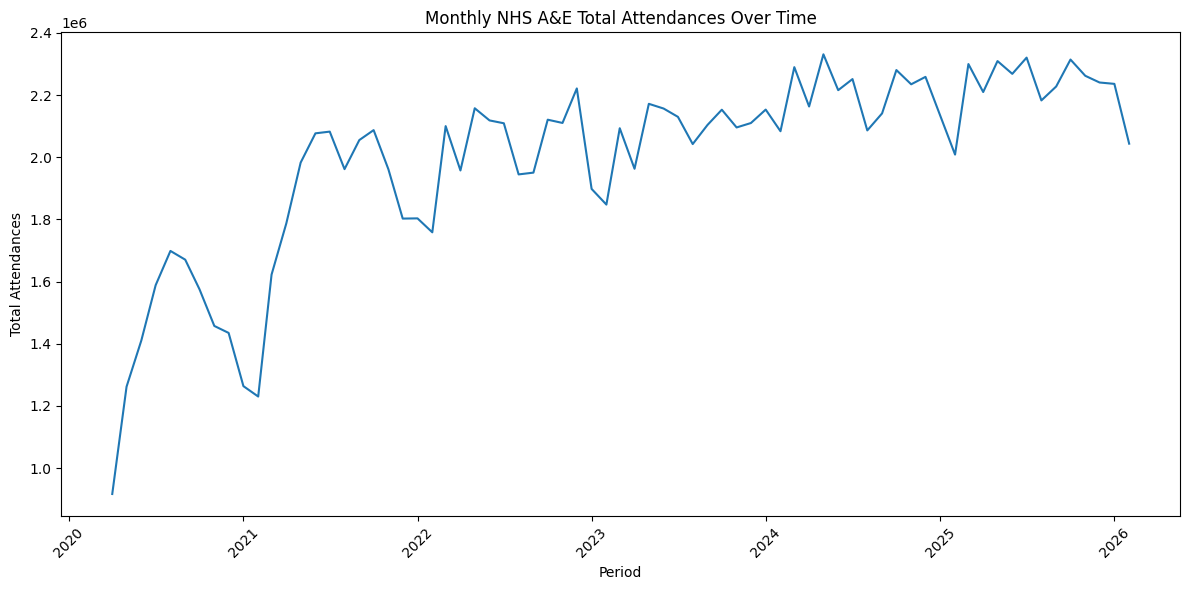

In [165]:
# Visualization: Monthly trend of total attendances
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(monthly_trend["period"]), monthly_trend["total_attendances"])
plt.title("Monthly NHS A&E Total Attendances Over Time")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

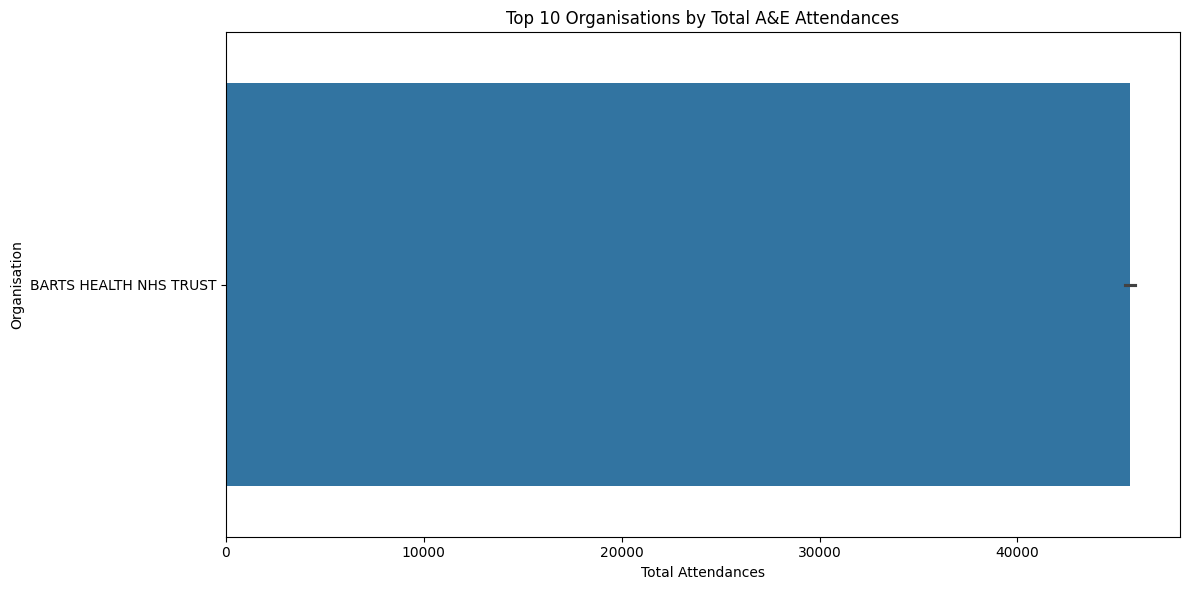

In [166]:
# Plot top 10 organisations by attendances
plt.figure(figsize=(12, 6))
sns.barplot(data=top_attendances, x="total_attendances", y="org_name")
plt.title("Top 10 Organisations by Total A&E Attendances")
plt.xlabel("Total Attendances")
plt.ylabel("Organisation")
plt.tight_layout()
plt.show()

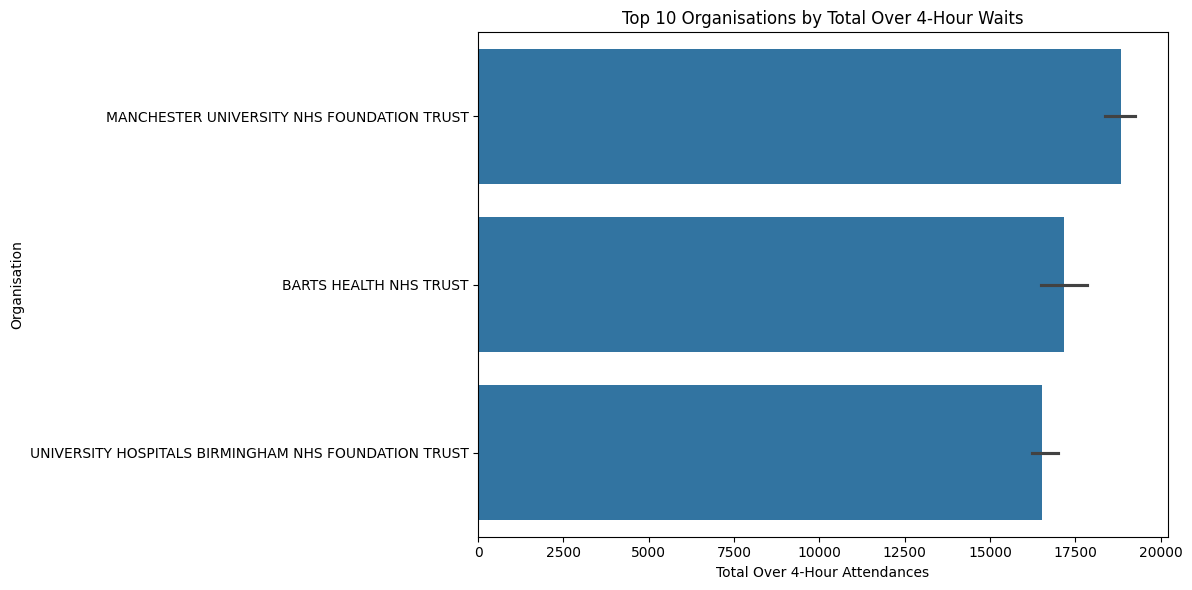

In [167]:
# Plot top 10 organisations by over 4-hour waits
plt.figure(figsize=(12, 6))
sns.barplot(data=top_over4, x="total_over_4hrs", y="org_name")
plt.title("Top 10 Organisations by Total Over 4-Hour Waits")
plt.xlabel("Total Over 4-Hour Attendances")
plt.ylabel("Organisation")
plt.tight_layout()
plt.show()

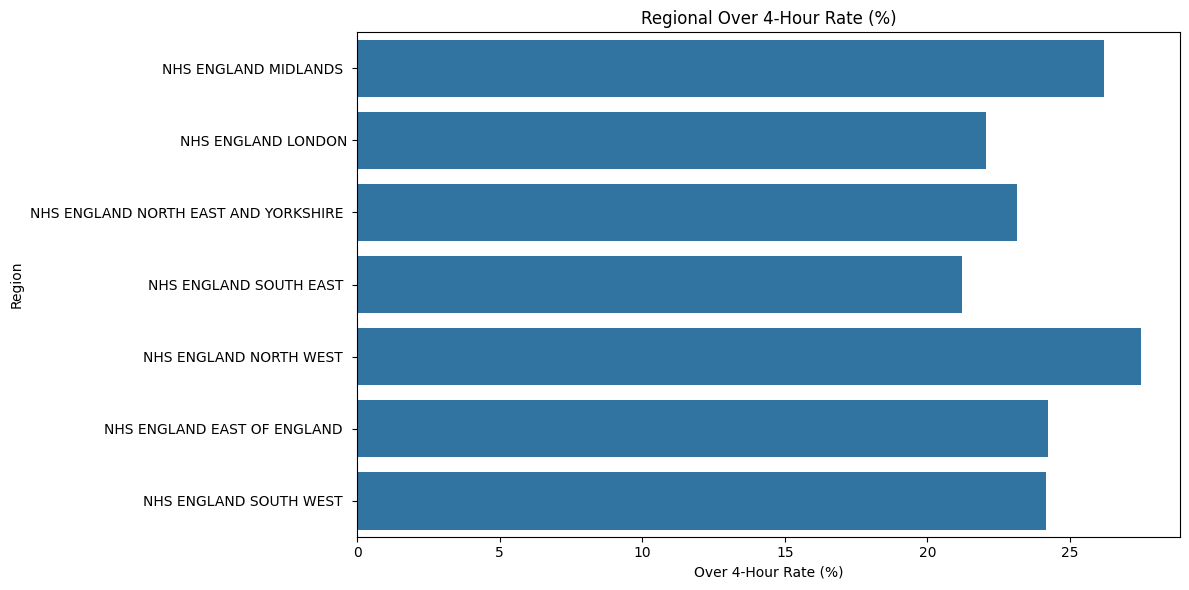

In [168]:
# Plot Regional over-4-hour rates
plt.figure(figsize=(12, 6))
sns.barplot(data=regional_summary, x="over_4hr_rate_pct", y="parent_org")
plt.title("Regional Over 4-Hour Rate (%)")
plt.xlabel("Over 4-Hour Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

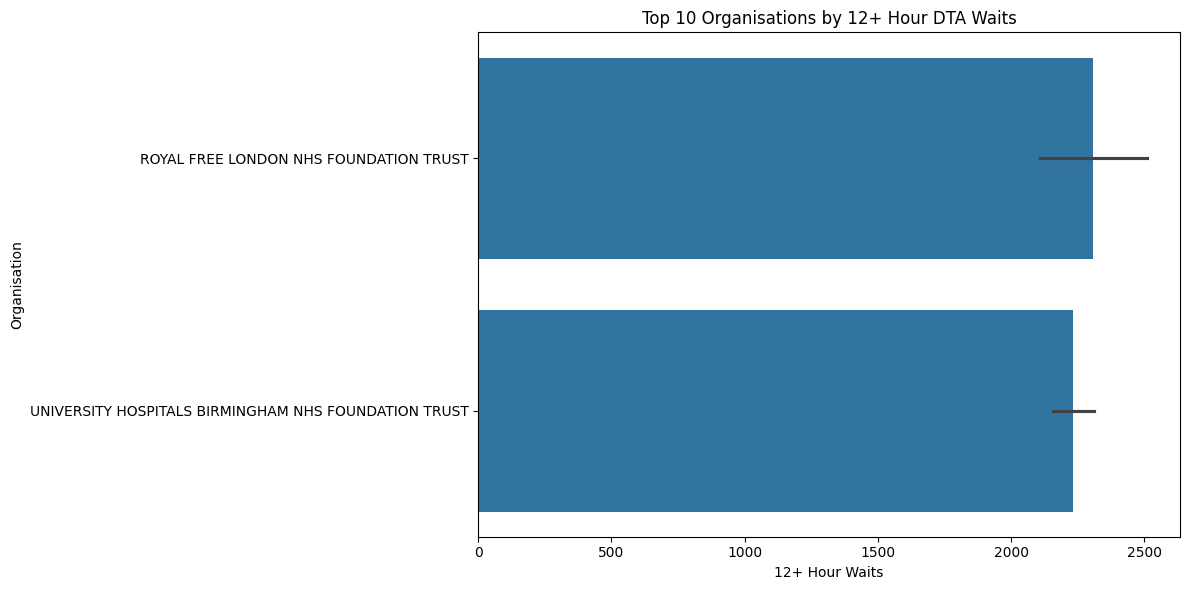

In [169]:
# top 10 by 12+ hour waits chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top_12plus, x="waits_12plus_hrs", y="org_name")
plt.title("Top 10 Organisations by 12+ Hour DTA Waits")
plt.xlabel("12+ Hour Waits")
plt.ylabel("Organisation")
plt.tight_layout()
plt.show()

## Key Insights

### 1. Demand pressure
The dataset shows strong variation in A&E demand across NHS organisations, with some trusts handling significantly larger attendance volumes than others.

### 2. Waiting time pressure
A number of organisations recorded very high volumes of attendances over 4 hours, showing operational strain and possible patient flow challenges.

### 3. Regional differences
Regional summaries indicate that A&E pressure is not evenly distributed across England.

### 4. Long waits
Some organisations reported especially high numbers of 12+ hour DTA waits, which may suggest bottlenecks in admission flow.

### 5. Admissions
Emergency admission rates also vary by organisation, indicating differences in case mix, acuity, or local service demand.

In [170]:
df.to_csv(processed_data_path, index=False)
print(f"Saved processed dataset to: {processed_data_path}")

Saved processed dataset to: ../data/processed/nhs_ae_full_2020_2026.csv


In [171]:
# Regional Summary
regional_summary.to_csv(regional_summary_path, index=False)
print(f"Regional summary exported to: {regional_summary_path}")

Regional summary exported to: ../data/processed/regional_summary_2020_2026.csv


In [172]:
# Top Trusts by waits
top_over4.to_csv(top_over4_path, index=False)
top_12plus.to_csv(top_12plus_path, index=False)
print(f"Top waits exported to: {top_over4_path} and {top_12plus_path}")

Top waits exported to: ../data/processed/top_10_over4_waits_2020_2026.csv and ../data/processed/top_10_12plus_waits_2020_2026.csv


In [173]:
# Close the database connection
conn.close()